# 04 - Expectation-Maximization Clustering

## E-Commerce Personalization Using EM Clustering and Deep Recommendation

### Objective

This notebook applies Expectation-Maximization clustering through
Gaussian Mixture Models (GMM) to identify distinct customer
behavioural segments.

The analysis uses the standardized customer-level behavioural
features prepared in Notebook 3.

### Key Questions

- How many customer segments provide an appropriate representation
  of customer behaviour?
- How does model fit change as the number of clusters increases?
- What do the resulting customer segments look like?
- Which customer behavioural characteristics distinguish the segments?

### Main Tasks

1. Load the standardized customer features.
2. Fit GMM models using different numbers of clusters.
3. Calculate AIC and BIC for each candidate model.
4. Select an appropriate number of clusters.
5. Assign customers to their most likely cluster.
6. Examine and interpret the resulting customer segments.
7. Visualize the cluster structure.

In [1]:
# Required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.mixture import GaussianMixture

# Load the output from Notebook 3 (customer_features_scaled.csv)
DATA_PATH = "customer_features_scaled.csv"

X_scaled = pd.read_csv(DATA_PATH)

print("Scaled feature matrix shape:", X_scaled.shape)
display(X_scaled.head())

Scaled feature matrix shape: (4338, 4)


,NumPurchases,TotalQuantity,TotalSpending,AvgUnitPrice
0,-0.425097,14.480825,8.363010,-0.100284
1,0.354417,0.251903,0.251699,-0.053398
2,-0.035340,0.228702,-0.027988,0.037825
3,-0.425097,-0.110379,-0.032406,0.111608
4,-0.425097,-0.196438,-0.190812,-0.018405


In [2]:
# Features used for clustering
print("Features used for clustering:")
print(X_scaled.columns.tolist())

Features used for clustering:
['NumPurchases', 'TotalQuantity', 'TotalSpending', 'AvgUnitPrice']


In [3]:
# Checking for missing values and infinite values before procceeding
print("\nMissing values:")
print(X_scaled.isnull().sum())

print("\nInfinite values:", np.isinf(X_scaled.to_numpy()).sum())


Missing values:
NumPurchases     0
TotalQuantity    0
TotalSpending    0
AvgUnitPrice     0
dtype: int64

Infinite values: 0


In [4]:
# Testing different number of clusters
cluster_range = range(2, 11)

aic_scores = []
bic_scores = []
models = []

In [5]:
# Fit the model
for k in cluster_range:
    gmm = GaussianMixture(
        n_components=k,
        covariance_type="full",
        random_state=42
    )
    
    gmm.fit(X_scaled)
    
    aic_scores.append(gmm.aic(X_scaled))
    bic_scores.append(gmm.bic(X_scaled))
    models.append(gmm)

In [6]:
# AIC/BIC Result table
model_selection = pd.DataFrame({
    "Clusters": list(cluster_range),
    "AIC": aic_scores,
    "BIC": bic_scores
})

display(model_selection)

,Clusters,AIC,BIC
0,2,3246.429248,3431.309140
1,3,-12628.080104,-12347.572681
2,4,-29083.044427,-28706.909474
3,5,-29384.492252,-28912.729769
4,6,-37794.314283,-37226.924269
5,7,-37827.385553,-37164.368010
6,8,-41149.081916,-40390.436842
7,9,-41449.381451,-40595.108846
8,10,-41634.780070,-40684.879935


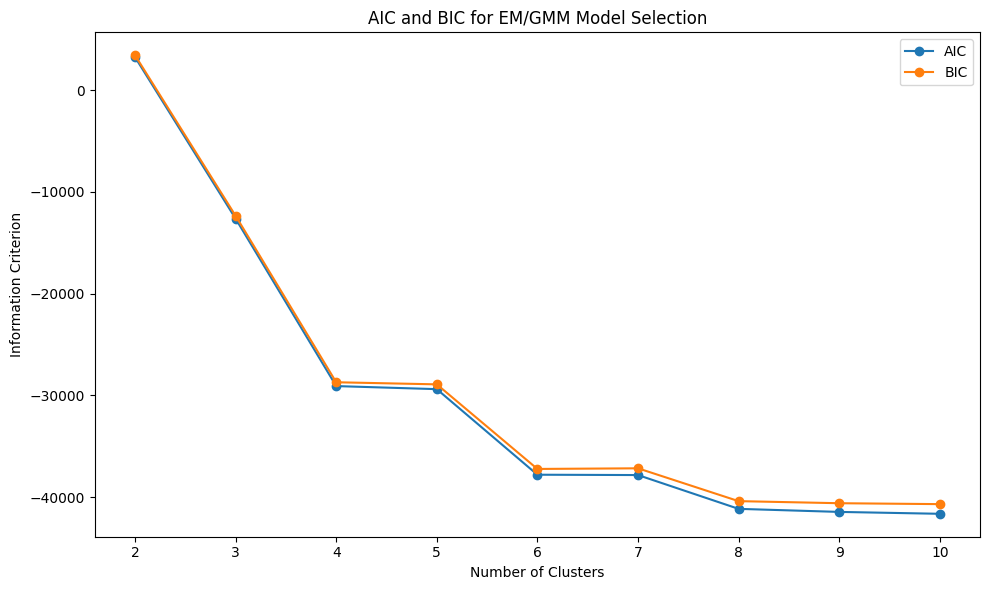

In [7]:
# Visualize AIC and BIC
plt.figure(figsize=(10, 6))

plt.plot(
    model_selection["Clusters"],
    model_selection["AIC"],
    marker="o",
    label="AIC"
)

plt.plot(
    model_selection["Clusters"],
    model_selection["BIC"],
    marker="o",
    label="BIC"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Information Criterion")
plt.title("AIC and BIC for EM/GMM Model Selection")
plt.xticks(list(cluster_range))
plt.legend()
plt.tight_layout()

plt.savefig(
    "aic_bic_model_selection.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Model Selection

AIC and BIC were evaluated across candidate Gaussian Mixture Models
with 2 to 10 clusters.

Both information criteria show a decreasing trend as the number of
clusters increases. The lowest observed AIC value is **-41634.780070**
at 10 clusters, while the lowest observed BIC value is
**-40684.879935**, also at 10 clusters.

The AIC/BIC visualization confirms that both criteria reach their
minimum observed values at **10 clusters**.

Therefore, based on the evaluated candidate models, the **10-cluster
solution is selected for the final EM/GMM analysis**.

The selected model is subsequently used to assign customers to their
most likely behavioural segments and to examine the characteristics
of each segment.

## Why 10 Clusters

10 clusters is the best-performing solution among the candidate models evaluated from 2 through 10 clusters according to both AIC and BIC.

In [8]:
# Fit the final EM/GMM Model
optimal_k = 10

final_gmm = GaussianMixture(
    n_components=optimal_k,
    covariance_type="full",
    random_state=42
)

final_gmm.fit(X_scaled)

print("Final GMM model fitted with", optimal_k, "clusters.")

Final GMM model fitted with 10 clusters.


In [9]:
# Generate customer cluster assignments
cluster_labels = final_gmm.predict(X_scaled)

customer_clusters = X_scaled.copy()
customer_clusters["Cluster"] = cluster_labels

display(customer_clusters.head())

,NumPurchases,TotalQuantity,TotalSpending,AvgUnitPrice,Cluster
0,-0.425097,14.480825,8.363010,-0.100284,1
1,0.354417,0.251903,0.251699,-0.053398,3
2,-0.035340,0.228702,-0.027988,0.037825,1
3,-0.425097,-0.110379,-0.032406,0.111608,6
4,-0.425097,-0.196438,-0.190812,-0.018405,0


In [10]:
# Calculating cluster membership
cluster_counts = (
    customer_clusters["Cluster"]
    .value_counts()
    .sort_index()
)

display(cluster_counts)

Cluster
0    1397
1     102
2       1
3    1049
4       1
5       1
6    1485
7     294
8       5
9       3
Name: count, dtype: int64

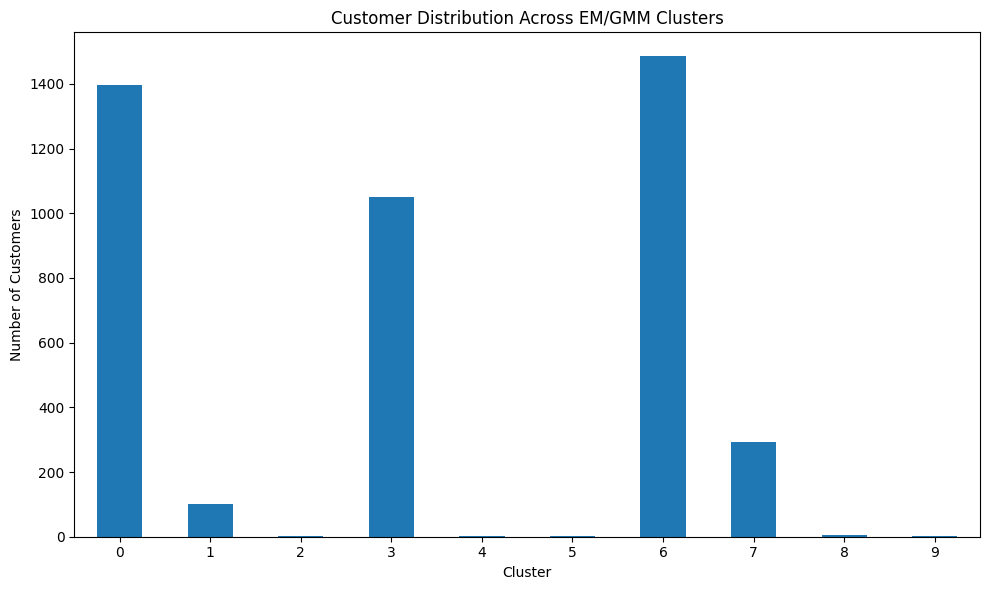

In [11]:
# Visualize cluster distribution
plt.figure(figsize=(10, 6))

cluster_counts.plot(kind="bar")

plt.title("Customer Distribution Across EM/GMM Clusters")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    "cluster_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [12]:
# Load the original customer features (Required for interpretation because clustering was performed on standardized features)
customer_features = pd.read_csv(
    "customer_features.csv"
)

display(customer_features.head())

,CustomerID,NumPurchases,TotalQuantity,TotalSpending,AvgUnitPrice
0,12346.0,1,74215,77183.60,1.040000
1,12347.0,7,2458,4310.00,2.644011
2,12348.0,4,2341,1797.24,5.764839
3,12349.0,1,631,1757.55,8.289041
4,12350.0,1,197,334.40,3.841176


In [13]:
# Attach the cluster labels
customer_features["Cluster"] = cluster_labels

display(customer_features.head())

,CustomerID,NumPurchases,TotalQuantity,TotalSpending,AvgUnitPrice,Cluster
0,12346.0,1,74215,77183.60,1.040000,1
1,12347.0,7,2458,4310.00,2.644011,3
2,12348.0,4,2341,1797.24,5.764839,1
3,12349.0,1,631,1757.55,8.289041,6
4,12350.0,1,197,334.40,3.841176,0


In [14]:
# Generating cluster profiles
cluster_profiles = (
    customer_features
    .groupby("Cluster")[
        [
            "NumPurchases",
            "TotalQuantity",
            "TotalSpending",
            "AvgUnitPrice"
        ]
    ]
    .mean()
)

display(cluster_profiles)

,NumPurchases,TotalQuantity,TotalSpending,AvgUnitPrice
Cluster,,,,
0,1.203293,125.435934,243.053644,3.557077
1,15.725490,11771.627451,18625.417157,18.171209
2,1.000000,1.000000,2033.100000,2033.100000
3,5.948522,1332.786463,2219.095959,2.889316
4,73.000000,196915.000000,280206.020000,2.493300
5,201.000000,80240.000000,143711.170000,4.612055
6,2.596633,418.088889,738.921402,3.098472
7,16.187075,4288.520408,7240.785850,2.779143
8,1.800000,806.400000,9095.708000,414.556000


In [15]:
# Calculate cluster proportions
cluster_summary = pd.DataFrame({
    "CustomerCount": cluster_counts,
    "Percentage": (
        cluster_counts / len(customer_features) * 100
    )
})

display(cluster_summary)

,CustomerCount,Percentage
Cluster,,
0,1397,32.203781
1,102,2.351314
2,1,0.023052
3,1049,24.181651
4,1,0.023052
5,1,0.023052
6,1485,34.232365
7,294,6.777317
8,5,0.115260


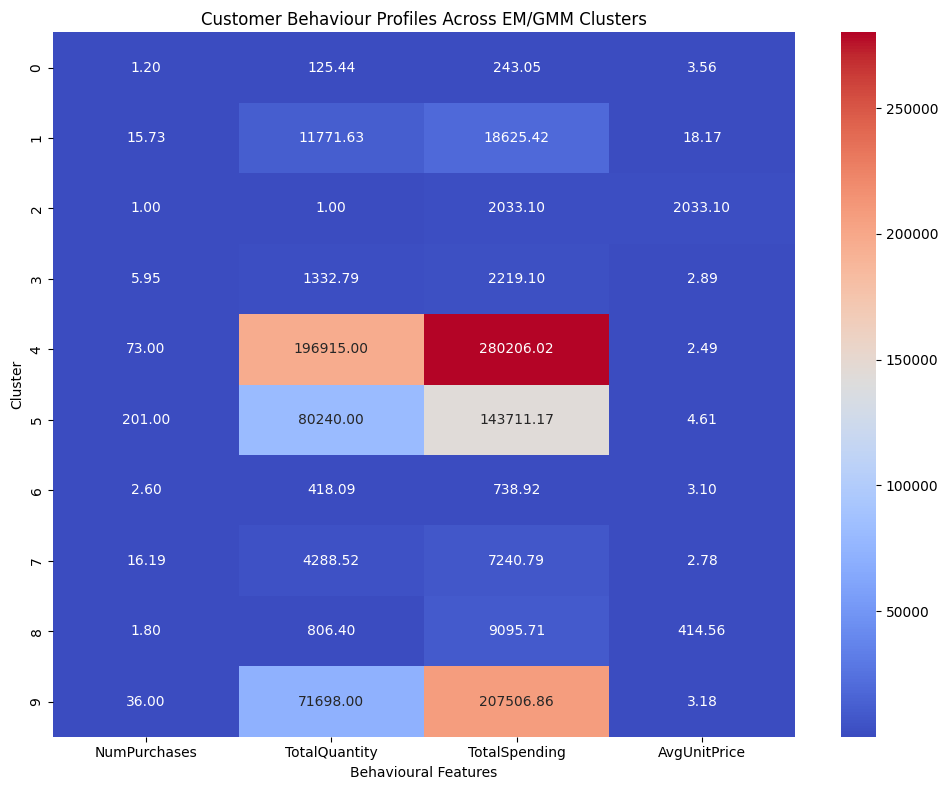

In [16]:
# Cluster profile visualization
plt.figure(figsize=(10, 8))

sns.heatmap(
    cluster_profiles,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Customer Behaviour Profiles Across EM/GMM Clusters")
plt.xlabel("Behavioural Features")
plt.ylabel("Cluster")
plt.tight_layout()

plt.savefig(
    "cluster_profiles.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [17]:
# Interpret the clusters
display(cluster_profiles)

,NumPurchases,TotalQuantity,TotalSpending,AvgUnitPrice
Cluster,,,,
0,1.203293,125.435934,243.053644,3.557077
1,15.725490,11771.627451,18625.417157,18.171209
2,1.000000,1.000000,2033.100000,2033.100000
3,5.948522,1332.786463,2219.095959,2.889316
4,73.000000,196915.000000,280206.020000,2.493300
5,201.000000,80240.000000,143711.170000,4.612055
6,2.596633,418.088889,738.921402,3.098472
7,16.187075,4288.520408,7240.785850,2.779143
8,1.800000,806.400000,9095.708000,414.556000


## Customer Segment Interpretation

The final EM/GMM model identifies **10 customer behavioural segments**.
The cluster profiles show meaningful differences in purchase frequency,
purchase quantity, spending level, and average unit price.

### Cluster 0 — Low-Activity, Low-Spending Customers

Cluster 0 has an average of approximately **1.20 purchases**, **125.44
units purchased**, and **243.05 in total spending**, with an average unit
price of **3.56**.

This segment represents relatively low-activity customers with low
overall transaction value.

### Cluster 1 — High-Value, High-Volume Customers

Cluster 1 records approximately **15.73 purchases**, **11,771.63 units**,
and **18,625.42 in total spending**, with an average unit price of
**18.17**.

This segment represents highly active customers with substantial
purchase volume and spending.

### Cluster 2 — Single-Purchase, High-Unit-Price Customers

Cluster 2 has an average of **1 purchase** and **1 unit**, but total
spending of **2,033.10**, which is also reflected in an average unit
price of **2,033.10**.

This indicates a small-volume, high-value transaction pattern
characterized by an unusually high unit price.

### Cluster 3 — Moderate-Activity Customers

Cluster 3 averages approximately **5.95 purchases**, **1,332.79 units**,
and **2,219.10 in total spending**, with an average unit price of
**2.89**.

This segment represents customers with moderate purchasing activity,
quantity, and spending.

### Cluster 4 — Extremely High-Volume Customers

Cluster 4 has approximately **73 purchases**, **196,915 units**, and
**280,206.02 in total spending**, with an average unit price of **2.49**.

This is one of the most substantial high-volume segments in the dataset,
with exceptionally high purchase quantity and total spending.

### Cluster 5 — Very High-Frequency, High-Value Customers

Cluster 5 records approximately **201 purchases**, **80,240 units**, and
**143,711.17 in total spending**, with an average unit price of **4.61**.

This segment is characterized by the highest average purchase frequency
among the identified clusters and substantial overall spending.

### Cluster 6 — Low-to-Moderate Activity Customers

Cluster 6 averages approximately **2.60 purchases**, **418.09 units**,
and **738.92 in total spending**, with an average unit price of **3.10**.

This segment represents relatively low-to-moderate purchasing activity
and spending.

### Cluster 7 — High-Volume, High-Spending Customers

Cluster 7 averages approximately **16.19 purchases**, **4,288.52 units**,
and **7,240.79 in total spending**, with an average unit price of **2.78**.

This segment represents relatively frequent customers with substantially
higher purchasing volume and spending than the lower-activity segments.

### Cluster 8 — High-Unit-Price Customers

Cluster 8 averages approximately **1.80 purchases**, **806.40 units**,
and **9,095.71 in total spending**, with an average unit price of
**414.56**.

The segment is distinguished by a very high average unit price compared
with most other customer groups.

### Cluster 9 — High-Volume, High-Spending Customers

Cluster 9 averages approximately **36 purchases**, **71,698 units**, and
**207,506.86 in total spending**, with an average unit price of **3.18**.

This segment represents highly active customers with very large purchase
volumes and exceptionally high total spending.

### Overall Interpretation

The clustering results demonstrate substantial heterogeneity in customer
behaviour. Some segments are characterized by low purchasing activity and
low spending, while others exhibit high purchase frequency, large
transaction volumes, or unusually high unit prices.

Clusters **2 and 8** are particularly distinguished by high average unit
prices, whereas Clusters **4, 5, 7, and 9** demonstrate substantially
higher purchasing activity, quantity, and/or spending.

These behavioural differences provide a useful segmentation layer for
personalized recommendation strategies and support the subsequent deep
recommendation stage of the project.

In [18]:
# Creating a cluster size summary
cluster_summary = pd.DataFrame({
    "CustomerCount": cluster_counts,
    "Percentage": (cluster_counts / len(customer_features)) * 100
})

cluster_summary.index.name = "Cluster"

display(cluster_summary)

,CustomerCount,Percentage
Cluster,,
0,1397,32.203781
1,102,2.351314
2,1,0.023052
3,1049,24.181651
4,1,0.023052
5,1,0.023052
6,1485,34.232365
7,294,6.777317
8,5,0.115260


In [19]:
# Create the PCA cluster visualization
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_clusters = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Cluster": cluster_labels
})

display(pca_clusters.head())

,PC1,PC2,Cluster
0,13.812619,0.070546,1
1,0.485096,-0.056865,3
2,0.105760,0.038015,1
3,-0.298785,0.121012,6
4,-0.448771,-0.012044,0


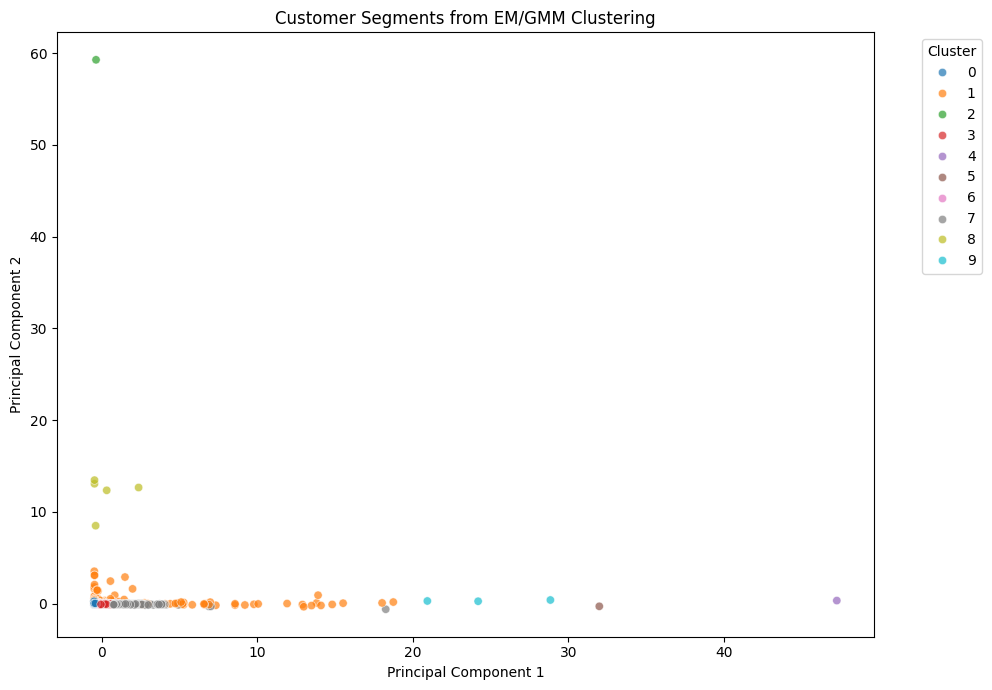

In [20]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_clusters,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="tab10",
    alpha=0.7
)

plt.title("Customer Segments from EM/GMM Clustering")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(
    title="Cluster",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    "customer_em_clusters.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Clustering Analysis Conclusion

The EM/GMM analysis identified **10 customer behavioural segments**
within the evaluated 2-to-10 cluster range. Both AIC and BIC reached
their lowest observed values at 10 clusters, providing support for the
selected model configuration.

The resulting cluster profiles demonstrate substantial variation in
customer purchasing behaviour. Differences are observed in purchase
frequency, total quantity, total spending, and average unit price.

The segmentation therefore provides a structured behavioural
representation of customers that can be incorporated into the next
stage of the hybrid personalization framework.

The resulting customer cluster assignments are saved for use in the
deep recommendation stage.

In [21]:
# Save the customer cluster assignment (for Notebook 5)
customer_features.to_csv(
    "customer_features_with_clusters.csv",
    index=False
)

print("Customer cluster assignments saved successfully.")

Customer cluster assignments saved successfully.


In [22]:
# Cross-check (Verify)
check = pd.read_csv(
    "customer_features_with_clusters.csv"
)

display(check.head())
print("Shape:", check.shape)
print("Clusters:", sorted(check["Cluster"].unique()))

,CustomerID,NumPurchases,TotalQuantity,TotalSpending,AvgUnitPrice,Cluster
0,12346.0,1,74215,77183.60,1.040000,1
1,12347.0,7,2458,4310.00,2.644011,3
2,12348.0,4,2341,1797.24,5.764839,1
3,12349.0,1,631,1757.55,8.289041,6
4,12350.0,1,197,334.40,3.841176,0


Shape: (4338, 6)
Clusters: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


## Notebook 4 Outputs

The EM/GMM clustering stage produced the following outputs:

- AIC and BIC model-selection analysis.
- Selection of the 10-cluster solution among the evaluated candidate
  models.
- Customer-level cluster assignments.
- Cluster membership counts and percentages.
- Behavioural profiles for the 10 customer segments.
- Customer cluster distribution visualization.
- Cluster profile heatmap.
- PCA-based visualization of the customer segments.
- `customer_features_with_clusters.csv`.

The identified behavioural segments form the customer-segmentation
component of the hybrid e-commerce personalization framework.

The next stage uses these customer segments as part of the input to
the deep recommendation model.